In [1]:
import numpy as np
proba = np.array([[0.1 , 0.85, 0.05],
                  [0.6 , 0.3 , 0.1 ],
                  [0.39, 0.61, 0.0 ]])

In [2]:
1 - proba.max(axis=1)

array([0.15, 0.4 , 0.39])

1. axis=1 means row-wise computation. In above output 0.15=1-0.85(1st row), 0.4=1-0.6(2nd row) and 0.39=1-0.61(3rd row)
2. In the above example, the most uncertain sample is the second one. When querying for labels based on this measure, the strategy selects the sample with the highest uncertainty.

In [3]:
import matplotlib.pyplot as plt
%matplotlib inline

from itertools import product
n_res = 100
p1, p2 = np.meshgrid(np.linspace(0, 1, n_res), np.linspace(0, 1, n_res))
p3 = np.maximum(1 - p1 - p2, 0)

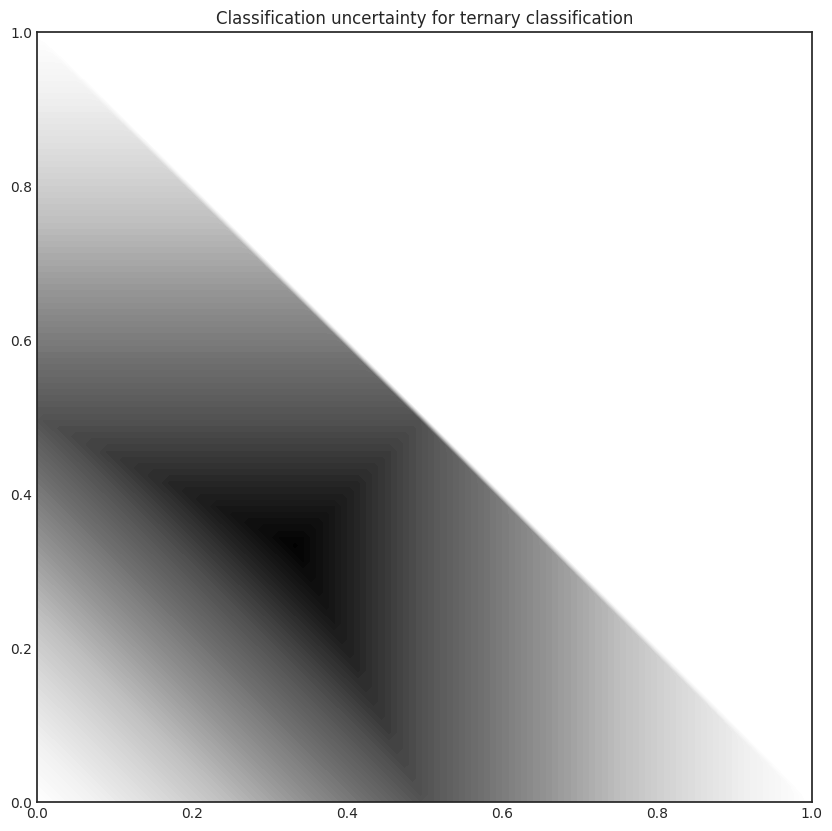

In [5]:
# np.maximum.reduce([A,B,C]):It first computes the np.maximum of A and B and then computes the np.maximum of (np.maximum of A and B) and C.

uncertainty = 1 - np.maximum.reduce([p1, p2, p3])

with plt.style.context('seaborn-white'):
    plt.figure(figsize=(10, 10))
    plt.contourf(p1, p2, uncertainty*((p1+p2) < 1), 100)
    plt.title('Classification uncertainty for ternary classification')

## Classification margin:
Classification margin is the difference in probability of the first and second most likely prediction

In [6]:
proba = np.array([[0.1 , 0.85, 0.05],
                  [0.6 , 0.3 , 0.1 ],
                  [0.39, 0.61, 0.0 ]])

In [8]:
part = np.partition(-proba, 1, axis=1)
print(part)
margin = - part[:, 0] + part[:, 1]
print(margin)

[[-0.85 -0.1  -0.05]
 [-0.6  -0.3  -0.1 ]
 [-0.61 -0.39 -0.  ]]
[0.75 0.3  0.22]


In [11]:
proba = np.vstack((p1.ravel(), p2.ravel(), p3.ravel())).T

part = np.partition(-proba, 1, axis=1)
margin = - part[:, 0] + part[:, 1]

margin = margin.reshape(p1.shape)



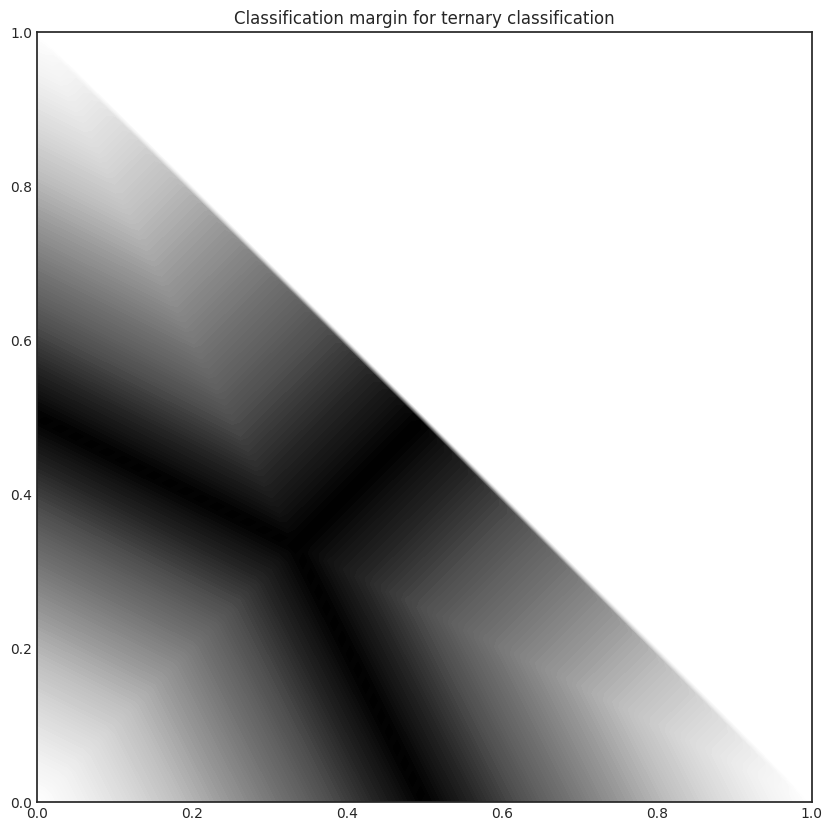

In [12]:
with plt.style.context('seaborn-white'):
    plt.figure(figsize=(10, 10))
    plt.contourf(p1, p2, (1-margin)*((p1+p2) < 1), 100)
    plt.title('Classification margin for ternary classification')

## Classification entropy:
 The entropy is proportional to the average number of guesses one has to make to find the true class.

In [9]:
proba = np.array([[0.1 , 0.85, 0.05],
                  [0.6 , 0.3 , 0.1 ],
                  [0.39, 0.61, 0.0 ]])

In [10]:
from scipy.stats import entropy

entropy(proba.T)

array([0.51818621, 0.89794572, 0.66874809])

The closer the distribution to uniform, the larger the entropy.

Again, if we plot the entropy against the first two probabilities of a ternary classification problem, we obtain the following.

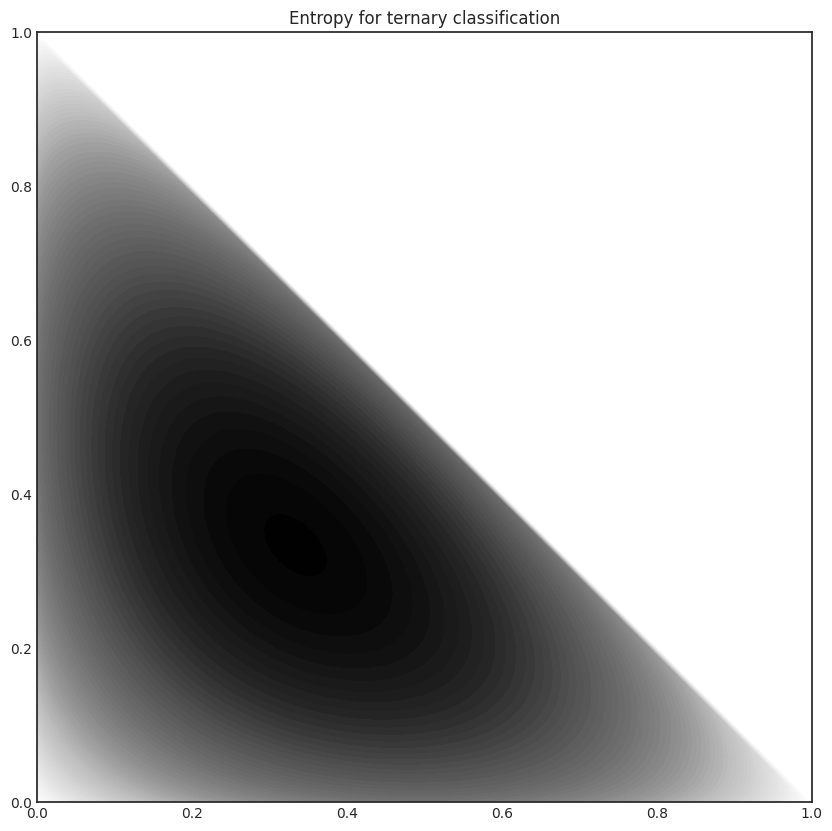

In [13]:
proba = np.vstack((p1.ravel(), p2.ravel(), p3.ravel())).T
entr = entropy(proba.T).reshape(p1.shape)

with plt.style.context('seaborn-white'):
    plt.figure(figsize=(10, 10))
    plt.contourf(p1, p2, entr*((p1+p2) < 1), 100)
    plt.title('Entropy for ternary classification')